# Week 1 — Numerical Linear Algebra Demo
Illustrates norms, conditioning, stability, and floating-point effects: the basic diagnostics used throughout the course to reason about how errors enter and grow in numerical linear algebra computations.

In [1]:
import numpy as np
from scipy.linalg import hilbert, solve_triangular
import matplotlib.pyplot as plt

## 1. Vector norms
Computes the 1-norm ($\sum_i |x_i|$), 2-norm (Euclidean length), and $\infty$-norm ($\max_i |x_i|$) of a vector. These are the standard ways to measure the "size" of a vector or an error, and different norms are preferred in different contexts (e.g. $\infty$-norm for worst-case error, 2-norm for least-squares).

In [2]:
x = np.array([1, -2, 3])
print(f'Vector norms for x = {x.T}:\n')
print(f'  ||x||_1  = {np.linalg.norm(x, 1):.4f}')
print(f'  ||x||_2  = {np.linalg.norm(x, 2):.4f}')
print(f'  ||x||_inf= {np.linalg.norm(x, np.inf):.4f}\n')

Vector norms for x = [ 1 -2  3]:

  ||x||_1  = 6.0000
  ||x||_2  = 3.7417
  ||x||_inf= 3.0000



## 2. Condition numbers
The condition number $\kappa(A) = \|A\|\,\|A^{-1}\|$ measures how much relative error in $b$ can be amplified in the solution $x$ of $Ax=b$. Three matrices are compared: the identity ($\kappa=1$, perfectly conditioned), a diagonal matrix with entries spanning $1$ to $10^4$ (moderately conditioned), and the $5\times5$ Hilbert matrix, a classic example of a matrix that is extremely ill-conditioned despite looking harmless.

In [3]:
I = np.eye(5)
D = np.diag(np.logspace(0, 4, 5))  # diag(1,10,100,1000,10000)
H = hilbert(5)

print('Condition numbers (2-norm):\n')
print(f'  Identity:        {np.linalg.cond(I):.2e}')
print(f'  Diagonal(1..1e4):{np.linalg.cond(D):.2e}')
print(f'  Hilbert(5x5):    {np.linalg.cond(H):.2e}\n')

Condition numbers (2-norm):

  Identity:        1.00e+00
  Diagonal(1..1e4):1.00e+04
  Hilbert(5x5):    4.77e+05



## 3. Catastrophic cancellation
Subtracting two nearly equal numbers is dangerous not because the subtraction is inaccurate, but because the answer comes out so small that the errors the inputs were already carrying are the same size as the answer itself.

Here $a = 1.0000000001$, $b = 1$, so $a - b = 10^{-10}$ exactly. Double precision resolves about 16 digits and copes. Single precision resolves about 7, so $a$ rounds to $1.0$ and the difference collapses to $0$ — a 100% error. This is Problem 5.


In [4]:
a = 1.0000000001
b = 1.0
exact  = 1e-10                                 # true difference
double = a - b
single = np.float32(a) - np.float32(b)         # force rounding to ~7 digits

print('Catastrophic cancellation:\n')
print(f'  true a - b        = {exact:.10e}')
print(f'  double precision  = {double:.10e}   rel. err = {abs(double - exact) / exact:.2e}')
print(f'  single precision  = {single:.10e}   rel. err = {abs(single - exact) / exact:.2e}\n')


Catastrophic cancellation:

  true a - b        = 1.0000000000e-10
  double precision  = 1.0000000827e-10   rel. err = 8.27e-08
  single precision  = 0.0000000000e+00   rel. err = 1.00e+00



### 3b. Unit roundoff $u$, the gap `eps`, and the concept check
`numpy.finfo(float).eps` $=2^{-52}$ is the **spacing** of the floats at 1; the unit roundoff $u = 2^{-53}$ is the **relative error bound**. Factor 2 apart, and they answer different questions. Note that the spacing is local — `math.ulp(1e16)` is 2, which is why $(1+10^{16})-10^{16}$ loses the 1 entirely.


In [5]:
import math
from decimal import Decimal

print('A', 0.1 + 0.2 == 0.3, ' ', Decimal(0.1 + 0.2), 'vs', Decimal(0.3))
print('B', 1.0 + 2**-53 == 1.0, ' ', (1.0 + 2**-53).hex())
print('C', 2**-53 == 0.0, ' ', float(2**-53).hex())
print('D', (1.0 + 1e16) - 1e16 == 1.0 + (1e16 - 1e16),
      ' ', (1.0 + 1e16) - 1e16, 'vs', 1.0 + (1e16 - 1e16))
print()
print(f'  gap at 1 (numpy eps)      = {np.finfo(float).eps}  = 2**-52')
print(f'  unit roundoff u           = {2**-53}  = 2**-53')
print(f'  smallest e with 1+e != 1  = {math.nextafter(2**-53, 1.0)}  = 2**-53 + 2**-105')
print(f'  gap at 1e16               = {math.ulp(1e16)}   <- the +1 falls off the end')


A False   0.3000000000000000444089209850062616169452667236328125 vs 0.299999999999999988897769753748434595763683319091796875
B True   0x1.0000000000000p+0
C False   0x1.0000000000000p-53
D False   0.0 vs 1.0

  gap at 1 (numpy eps)      = 2.220446049250313e-16  = 2**-52
  unit roundoff u           = 1.1102230246251565e-16  = 2**-53
  smallest e with 1+e != 1  = 1.1102230246251568e-16  = 2**-53 + 2**-105
  gap at 1e16               = 2.0   <- the +1 falls off the end


## 4. Effect of conditioning on solving systems
Solves $Ax=b$ for the same right-hand side with a well-conditioned matrix $A_1$ and a nearly singular matrix $A_2$ (rows almost linearly dependent). Even though $A_2$ is only a tiny perturbation away from $A_1$, its much larger condition number leads to a solution that is far more sensitive to small changes in the data.

In [6]:
A1 = np.array([[1, 2], [3, 4]])
A2 = np.array([[1, 1], [1, 1.0001]])
b_sys = np.array([5, 11])

x1 = np.linalg.solve(A1, b_sys)
x2 = np.linalg.solve(A2, b_sys)

print('Effect of conditioning:\n')
print(f'  Solution with A1 (cond={np.linalg.cond(A1):.2e}): x = {x1.T}')
print(f'  Solution with A2 (cond={np.linalg.cond(A2):.2e}): x = {x2.T}\n')

Effect of conditioning:

  Solution with A1 (cond=1.49e+01): x = [1. 2.]
  Solution with A2 (cond=4.00e+04): x = [-59995.00000001  60000.00000001]



## 5. Floating-point summation stability
Sums the harmonic series $\sum_{k=1}^{N}1/k$ with $N=10^7$ in single precision, in both orders, against a double-precision reference. Adding the **small terms first** accumulates them into a partial sum of comparable magnitude before the large ones arrive. Adding the **large terms first** is far worse: once the running sum exceeds $10$, a term $1/k$ falls below half an ulp of the accumulator and is lost entirely --- *stagnation*. These are the numbers quoted in the solution to Problem 6.

In [7]:
# Harmonic series in single precision, summed in both orders (Problem 6 of Chapter 1).
# np.cumsum accumulates sequentially, so its last entry is the naive running sum;
# np.sum would use pairwise summation and hide the effect.
N = 10**7
terms = np.float32(1.0) / np.arange(1, N + 1, dtype=np.float32)
large_first = np.cumsum(terms, dtype=np.float32)[-1]            # 1, 1/2, 1/3, ...
small_first = np.cumsum(terms[::-1], dtype=np.float32)[-1]      # ..., 1/3, 1/2, 1
reference = np.cumsum(1.0 / np.arange(1, N + 1, dtype=np.float64))[-1]
print('Summation order matters (harmonic series, N = 1e7):\n')
print(f'  single precision, large terms first : {large_first:.7f}')
print(f'  single precision, small terms first : {small_first:.7f}')
print(f'  double precision (reference)        : {reference:.7f}\n')


Summation order matters (harmonic series, N = 1e7):

  single precision, large terms first : 15.4036827
  single precision, small terms first : 16.6860313
  double precision (reference)        : 16.6953114



## 6. Fixed point iterations for SOAR correlation function
Builds a dense, circulant correlation matrix $C$ from the SOAR (second-order autoregressive) correlation function $C_{ij} = (1+d_{ij})e^{-d_{ij}}$, where $d_{ij}$ is a scaled great-circle-like distance between indices $i$ and $j$ on a periodic grid. The linear system $Cx=b$ is then solved with three classical stationary (fixed-point) iterative methods — Jacobi, Gauss-Seidel, and SOR — so their convergence behavior can be compared on the same problem.

In [8]:
n_soar = 100
L_soar = 0.4
a_soar = 1

# construct SOAR matrix (vectorized)
i, l = np.mgrid[0:n_soar, 0:n_soar]
theta_j = (2 * np.pi / n_soar) * np.abs(i - l)
dist = np.abs(2 * a_soar * np.sin(theta_j / 2)) / L_soar
C = (1 + dist) * np.exp(-dist)

# Iteration parameters
maxit = 5000
tol = 1e-5
x0 = np.zeros(n_soar)
b_soar = np.ones(n_soar)
norm_b = np.linalg.norm(b_soar)

### Jacobi
Splits $C = D - L - U$ (diagonal, strictly lower, strictly upper parts) and iterates $x^{k+1} = D^{-1}(L+U)x^k + D^{-1}b$, using only values from the previous iterate $x^k$.

In [8]:
D = np.diag(np.diag(C))
L = -np.tril(C, -1)
U = -np.triu(C, 1)
invD = np.diag(1 / np.diag(D))
GJ = invD @ (L + U)
cJ = invD @ b_soar
x = x0.copy()
resJ = [np.linalg.norm(b_soar - C @ x0) / norm_b]
for k in range(maxit):
    x = GJ @ x + cJ
    res = np.linalg.norm(b_soar - C @ x) / norm_b
    resJ.append(res)
    if res < tol:
        break

### Gauss-Seidel
Uses the same splitting but solves $(D-L)x^{k+1} = Ux^k + b$ by forward substitution, so each component of $x^{k+1}$ immediately uses the already-updated components — typically converging faster than Jacobi.

In [9]:
M = D - L
x = x0.copy()
resGS = [np.linalg.norm(b_soar - C @ x0) / norm_b]
for k in range(maxit):
    # Forward substitution to solve M*x_new = U*x + b
    x_new = solve_triangular(M, U @ x + b_soar, lower=True)
    x = x_new
    res = np.linalg.norm(b_soar - C @ x) / norm_b
    resGS.append(res)
    if res < tol:
        break

### SOR
Successive Over-Relaxation extrapolates the Gauss-Seidel step with a relaxation factor $\omega$: $(\tfrac{1}{\omega}D - L)x^{k+1} = (\tfrac{1-\omega}{\omega}D + U)x^k + b$.

Instead of a closed form which we don't have, $\omega$ below is chosen by directly searching for the value that minimizes the spectral radius of the SOR iteration matrix for *this* $C$, which gives a modest (not dramatic) improvement over Gauss-Seidel — consistent with this matrix lacking the structure that makes SOR so effective on model PDE problems.

In [10]:
# Numerically search for the omega that minimizes the SOR iteration matrix's
# spectral radius on THIS matrix C (the Poisson closed-form formula doesn't apply).
def sor_spectral_radius(w):
    M_w = (1 / w) * D - L
    N_w = (1 - w) / w * D + U
    Gw = np.linalg.solve(M_w, N_w)
    return np.max(np.abs(np.linalg.eigvals(Gw)))

omega_grid = np.linspace(0.1, 1.99, 100)
rhos = [sor_spectral_radius(w) for w in omega_grid]
omega = omega_grid[np.argmin(rhos)]
print(f'Numerically chosen omega = {omega:.4f} (spectral radius = {min(rhos):.5f})')

M_sor = (1/omega) * D - L
N_sor = (1-omega)/omega * D + U
x = x0.copy()
resSOR = [np.linalg.norm(b_soar - C @ x0) / norm_b]
for k in range(maxit):
    # Forward substitution: M_sor * x_new = N_sor * x + b
    rhs = N_sor @ x + b_soar
    x_new = solve_triangular(M_sor, rhs, lower=True)
    x = x_new
    res = np.linalg.norm(b_soar - C @ x) / norm_b
    resSOR.append(res)
    if res < tol:
        break

Numerically chosen omega = 1.3982 (spectral radius = 0.99864)


### Compare convergence
Plots the relative residual norm $\|b-Cx^k\|/\|b\|$ against iteration count on a log scale for all three methods, making it easy to compare their convergence rates directly.

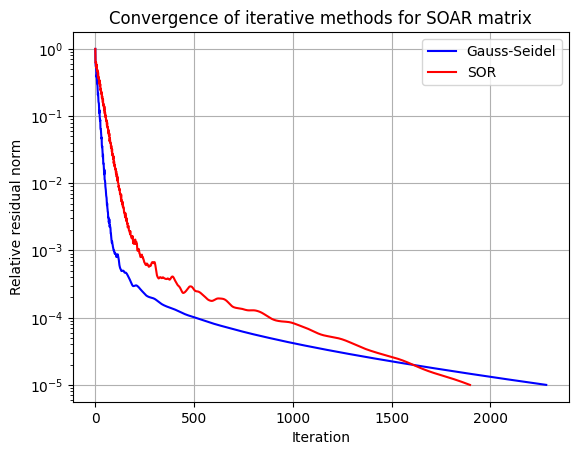

In [11]:
plt.figure()
plt.semilogy(resGS, 'b-', label='Gauss-Seidel')
plt.semilogy(resSOR, 'r-', label='SOR')
# plt.semilogy(resJ, 'k-', label='Jacobi')  # diverges on this matrix (rho(G_J) ≈ 27) — see note below
plt.xlabel('Iteration')
plt.ylabel('Relative residual norm')
plt.title('Convergence of iterative methods for SOAR matrix')
plt.legend()
plt.grid(True)
plt.show()

### Why does Jacobi diverge here?
The plot shows Jacobi's residual exploding while Gauss-Seidel and SOR converge steadily on the same matrix $C$. This reflects a genuine difference in convergence guarantees:

- $C$ is symmetric positive definite (SPD), since it is built from a valid correlation function, but it is far from diagonally dominant. **Jacobi** only converges if the iteration matrix $G_J = D^{-1}(L+U)$ has spectral radius less than $1$. For this $C$, $\rho(G_J) \approx 27$, so each iteration amplifies the error by roughly $27\times$ — the residual overflows to `inf`/`nan` within a couple hundred iterations.
- **Gauss-Seidel** and **SOR** with $0<\omega<2$ are *guaranteed* to converge for *any* SPD matrix, independent of diagonal dominance (classical Gauss-Seidel and Ostrowski-Reich theorems). That guarantee is why they still converge smoothly on this same, poorly diagonally-dominant $C$ while Jacobi diverges catastrophically.

In short: diagonal dominance (or an equivalent condition) is required for Jacobi to converge, but SPD alone is enough for Gauss-Seidel/SOR — and this SOAR correlation matrix satisfies the latter but badly violates the former.